# Environment Setup


In [ ]:
# Install core NLP libraries (Transformers, Datasets, Accelerate, SentencePiece)
!pip install -q "transformers>=4.42.0" "datasets>=2.20.0" "accelerate>=0.30.0" sentencepiece

# Install data processing & evaluation libraries
!pip install -q pandas numpy scikit-learn

# Install visualization tools
!pip install -q matplotlib seaborn

# Install wandb only to avoid auto-login errors (we won't use tracking)
!pip install -q wandb



# Import Libraries


In [ ]:

# Ignore warnings to keep notebook output clean
import warnings
warnings.filterwarnings('ignore')

# JSON & Colab file utilities
import json
from google.colab import files

# Base libraries
import re
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Disable wandb (avoid auto-login errors in Colab/Kaggle)
import wandb
wandb.init(mode="disabled")

# Progress bar
from tqdm.auto import tqdm

# HuggingFace: Dataset handling
from datasets import Dataset

# Suppress transformers logging (cleaner output)
from transformers.utils import logging
logging.set_verbosity_error()

# Sklearn: split & metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

# HuggingFace training modules
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

# Plot style settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Environment check
print("Environment Loaded | GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


Environment Loaded | GPU: Tesla T4


# Load Dataset from Local (Upload to Colab)



In [ ]:

print("Upload Kaggle CSV file from your computer")
uploaded = files.upload()  # user selects file manually

# Get uploaded filename
csv_filename = list(uploaded.keys())[0]

# Read CSV into DataFrame
df = pd.read_csv(csv_filename)

# Preview first rows
print("\nPreview dataframe:")
display(df.head())

# Check label distribution
print("\nLabel distribution:")
print(df['sentiment'].value_counts())


Upload Kaggle CSV file from your computer


Saving 23k_r_gaming_comments_sentiments.csv to 23k_r_gaming_comments_sentiments.csv

Preview dataframe:


,Unnamed: 0,Comment,sentiment
0,0,Them: I don't think I like this game.\n\nMe: B...,negative
1,1,Then you leave them to farm the smaller creatu...,negative
2,2,Nothing beats the feeling you get when you see...,positive
3,3,"[Also, they're made of paper](https://i.imgur....",negative
4,4,Haha... That was exactly it when my brother tr...,positive



Label distribution:
sentiment
positive    10034
neutral      9083
negative     4072
Name: count, dtype: int64


# Balance dataset (Undersampling)

In [ ]:
label_col = "sentiment"
text_col = "Comment"

# Ensure label is string (e.g., "positive", "neutral", "negative")
df[label_col] = df[label_col].astype(str)

print("Original label distribution:")
print(df[label_col].value_counts(), "\n")

# Get min samples per class
class_counts = df[label_col].value_counts()
min_count = class_counts.min()

# Undersample each class to match smallest group
balanced_df = df.groupby(label_col).apply(
    lambda x: x.sample(min_count, random_state=42)
).reset_index(drop=True)

print("Balanced dataset distribution (undersampling):")
print(balanced_df[label_col].value_counts())

Original label distribution:
sentiment
positive    10034
neutral      9083
negative     4072
Name: count, dtype: int64 

Balanced dataset distribution (undersampling):
sentiment
negative    4072
neutral     4072
positive    4072
Name: count, dtype: int64


#Train/Val/Test Split

In [ ]:
train_df, temp_df = train_test_split(
    balanced_df, test_size=0.3, stratify=balanced_df[label_col], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df[label_col], random_state=42
)

print("📊 Dataset Split Summary")
print("-" * 50)
print(f"🟩 Training set:      {len(train_df):,} samples")
print(f"🟦 Validation set:    {len(val_df):,} samples")
print(f"🟥 Test set:          {len(test_df):,} samples")
print("-" * 50)
print(f"✅ Total:             {len(train_df) + len(val_df) + len(test_df):,} samples")
print(f"📎 Columns: {list(df.columns)}")

📊 Dataset Split Summary
--------------------------------------------------
🟩 Training set:      8,551 samples
🟦 Validation set:    1,832 samples
🟥 Test set:          1,833 samples
--------------------------------------------------
✅ Total:             12,216 samples
📎 Columns: ['Unnamed: 0', 'Comment', 'sentiment']


#Tokenizer + Label Encoding


In [ ]:
MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)

# Ensure labels are string
df[label_col] = df[label_col].astype(str)

# Create label2id / id2label mapping
label2id = {label: i for i, label in enumerate(sorted(df[label_col].unique()))}
id2label = {v: k for k, v in label2id.items()}

print("Label mapping:", label2id)

# Apply numerical labels for HF training
train_df["label"] = train_df[label_col].map(label2id)
val_df["label"]   = val_df[label_col].map(label2id)
test_df["label"]  = test_df[label_col].map(label2id)

# Tokenizer function
def tokenize(example):
    return tokenizer(
        example[text_col],
        truncation=True,
        padding="max_length",
        max_length=128
    )

# Convert to HF datasets
train_data = Dataset.from_pandas(train_df[["label", text_col]]).map(tokenize, batched=True)
val_data   = Dataset.from_pandas(val_df[["label", text_col]]).map(tokenize, batched=True)
test_data  = Dataset.from_pandas(test_df[["label", text_col]]).map(tokenize, batched=True)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


Map:   0%|          | 0/8551 [00:00<?, ? examples/s]

Map:   0%|          | 0/1832 [00:00<?, ? examples/s]

Map:   0%|          | 0/1833 [00:00<?, ? examples/s]

#Create & Configure Model

In [ ]:
# Load pre-trained RoBERTa for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
).to('cuda')

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",              # Where to save model checkpoints
    eval_strategy="epoch",               # Evaluate at the end of each epoch
    save_strategy="epoch",               # Save model at the end of each epoch
    num_train_epochs=3,                  # Total training epochs
    per_device_train_batch_size=16,      # Batch size per device (GPU/CPU) for training
    per_device_eval_batch_size=16,       # Batch size per device for evaluation
    learning_rate=2e-5,                  # Learning rate
    logging_dir='./logs',                # Directory for logs
    logging_steps=50,                    # Log every 50 steps
    report_to="none"                     # Disable W&B logging
)

#Initialize Trainer & Start Training

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    data_collator=DataCollatorWithPadding(tokenizer),
)

# Print training info
print("="*60)
print("🔥 STARTING TRAINING (STAGE 2)")
print("="*60)
print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print("="*60)

# Start fine-tuning
train_result = trainer.train()

# Print results
print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print("="*60)
print(f"   Final loss: {train_result.training_loss:.4f}")
print(f"   Total time: {train_result.metrics['train_runtime']:.2f}s")

🔥 STARTING TRAINING (STAGE 2)
Training samples: 8551
Validation samples: 1832
{'loss': 0.8178, 'grad_norm': 18.744611740112305, 'learning_rate': 1.9389408099688476e-05, 'epoch': 0.09345794392523364}
{'loss': 0.7087, 'grad_norm': 8.597372055053711, 'learning_rate': 1.8766355140186918e-05, 'epoch': 0.18691588785046728}
{'loss': 0.6497, 'grad_norm': 19.654010772705078, 'learning_rate': 1.814330218068536e-05, 'epoch': 0.2803738317757009}
{'loss': 0.5972, 'grad_norm': 12.532670021057129, 'learning_rate': 1.7520249221183802e-05, 'epoch': 0.37383177570093457}
{'loss': 0.6085, 'grad_norm': 22.00106430053711, 'learning_rate': 1.6897196261682244e-05, 'epoch': 0.4672897196261682}
{'loss': 0.5938, 'grad_norm': 8.741955757141113, 'learning_rate': 1.6274143302180686e-05, 'epoch': 0.5607476635514018}
{'loss': 0.581, 'grad_norm': 15.481134414672852, 'learning_rate': 1.5651090342679128e-05, 'epoch': 0.6542056074766355}
{'loss': 0.4895, 'grad_norm': 22.891761779785156, 'learning_rate': 1.502803738317757

#Evaluate on Test Set


✅ Overall Metrics:
   Accuracy:  0.8467 (84.67%)
   F1-Score:  0.8464

📊 Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.87      0.85       611
     neutral       0.86      0.80      0.83       611
    positive       0.86      0.87      0.86       611

    accuracy                           0.85      1833
   macro avg       0.85      0.85      0.85      1833
weighted avg       0.85      0.85      0.85      1833



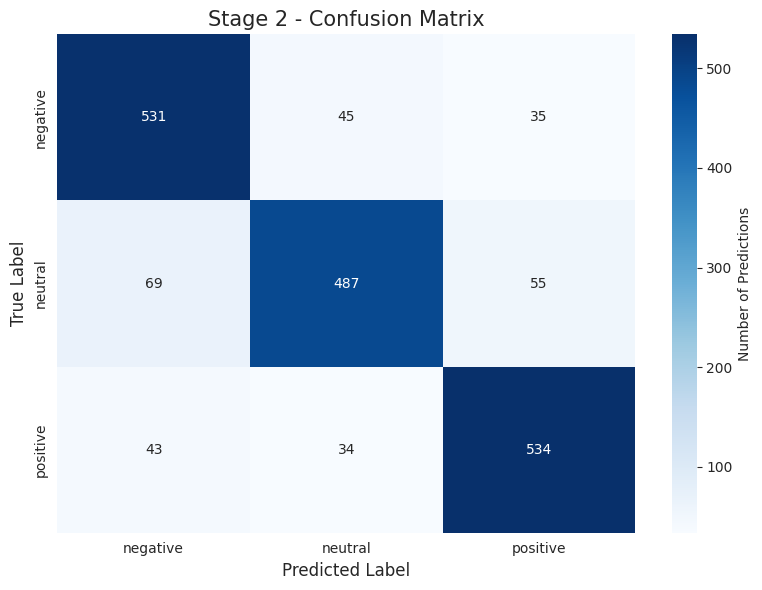

In [ ]:
# Get predictions from the trainer
pred_output = trainer.predict(test_data)

# Predicted label indices
pred_labels = np.argmax(pred_output.predictions, axis=1)

# True label indices
true_labels = pred_output.label_ids

# Convert IDs to text labels
true_text = [id2label[int(x)] for x in true_labels]
pred_text = [id2label[int(x)] for x in pred_labels]

# Overall metrics
print(f"\n✅ Overall Metrics:")
acc = accuracy_score(true_labels, pred_labels)
f1 = f1_score(true_labels, pred_labels, average='weighted')
print(f"   Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"   F1-Score:  {f1:.4f}")

# Classification report per class
print("\n📊 Classification Report:")
print(classification_report(true_text, pred_text, labels=list(label2id.keys())))

# Confusion matrix
unique_labels = list(id2label.values())
cm = confusion_matrix(true_text, pred_text, labels=unique_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',  # customize color if needed
    xticklabels=unique_labels,
    yticklabels=unique_labels,
    cbar_kws={'label': 'Number of Predictions'}
)
plt.title("Stage 2 - Confusion Matrix", fontsize=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()

#Save Results & Model

In [ ]:

# Prepare results dictionary
results = {
    'stage': 2,
    'method': 'Supervised Learning (Fine-tune on balanced dataset)',
    'dataset': 'Kaggle Game Reviews',
    'dataset_size': len(df),
    'train_size': len(train_df),
    'val_size': len(val_df),
    'test_size': len(test_df),
    'model': MODEL,
    'epochs': training_args.num_train_epochs,
    'batch_size': training_args.per_device_train_batch_size,
    'learning_rate': training_args.learning_rate,
    'metrics': {
        'accuracy': float(acc),
        'f1_weighted': float(f1),
    },
    'class_distribution': df[label_col].value_counts().to_dict(),
    'training_time_seconds': train_result.metrics['train_runtime']
}

# Save results to JSON
with open('stage2_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("💾 Results saved to: stage2_results.json")

# Save model & tokenizer
model_path = './stage2_roberta_balanced_final'
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

print(f"💾 Model saved to: {model_path}")

# Download results JSON from Colab
print("📥 Downloading results...")
files.download('stage2_results.json')

print("\n✅ Stage 2 complete!")

💾 Results saved to: stage2_results.json
💾 Model saved to: ./stage2_roberta_balanced_final
📥 Downloading results...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Stage 2 complete!
